## Partea 2:Preprocesare

Observam din partea 1 ca dataset ul nu prezinta valori duplicate sau valori lipsa si nu a fost nevoie de transformarea valorilor categorice tip string in valori numerice fiind deja transformate in dataset ul primit.

In schimb am observat ca anumite coloane prezinta un numar mare de outliers astfel ca vom folosii RobustScaler pentru a scala numeric valorile(chiar daca pentru XGBoost nu este neaparat obligatoriu,modelul ocupandu-se deja de astfel de probleme)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

df = pd.read_csv('datasets/australian_analysed.dat', sep=' ')

x = df.drop('A15', axis=1)
y = df['A15']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# 4) scalare pentru coloanele cu % mare de outliers
cols_de_scalat = ['A7', 'A10', 'A14']
scaler = RobustScaler()

x_train[cols_de_scalat] = scaler.fit_transform(x_train[cols_de_scalat])
x_test[cols_de_scalat] = scaler.transform(x_test[cols_de_scalat])

print(f'Dimensiune X: {x.shape}')
print(f'Dimensiune y: {y.shape}')
print(f'Dimensiune X_train: {x_train.shape}')
print(f'Dimensiune X_test : {x_test.shape}')
print(f'Dimensiune y_train: {y_train.shape}')
print(f'Dimensiune y_test : {y_test.shape}')


df.to_csv("datasets/australian_preprocessed.dat", sep=" ", index=False)

Dimensiune X: (690, 14)
Dimensiune y: (690,)
Dimensiune X_train: (552, 14)
Dimensiune X_test : (138, 14)
Dimensiune y_train: (552,)
Dimensiune y_test : (138,)


## Partea 3: Modelare si evaluare

Am antrenat un model XGBoost, l-am evaluam cu mai multe metrici si am testat variante de hiperparametri salvand modelul cu rezultatele cele mai bune.


Rezultate (sortate dupa F1):
 id  max_depth  n_estimators  learning_rate  accuracy  precision   recall       f1
 15          6           100           0.30  0.884058   0.846154 0.901639 0.873016
 18          6           200           0.30  0.884058   0.857143 0.885246 0.870968
  3          3            50           0.30  0.869565   0.802817 0.934426 0.863636
 27         10           200           0.30  0.869565   0.820896 0.901639 0.859375
 24         10           100           0.30  0.869565   0.820896 0.901639 0.859375
  8          3           200           0.10  0.862319   0.808824 0.901639 0.852713
 26         10           200           0.10  0.862319   0.818182 0.885246 0.850394
 21         10            50           0.30  0.855072   0.797101 0.901639 0.846154
 23         10           100           0.10  0.855072   0.815385 0.868852 0.841270
  9          3           200           0.30  0.855072   0.815385 0.868852 0.841270
  6          3           100           0.30  0.855072   0.

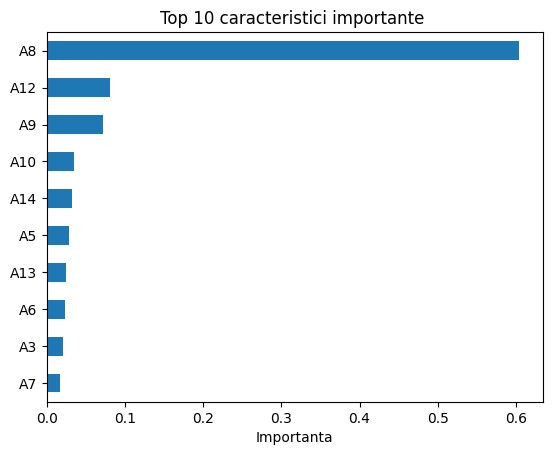

In [ ]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


def calc_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred), 
        'recall': recall_score(y_true, y_pred),       
        'f1': f1_score(y_true, y_pred),
    }

#hiperparametrii
max_depth_values = [3, 6, 10]
n_estimators_values = [50, 100, 200]
learning_rate_values = [0.01, 0.1, 0.3]

results = []
best_model = None
best_params = None
best_f1 = -1.0
id = 0

for max_depth in max_depth_values:
    for n_estimators in n_estimators_values:
        for learning_rate in learning_rate_values:
            id += 1

            params = {
                'max_depth': max_depth,
                'n_estimators': n_estimators,
                'learning_rate': learning_rate,
            }

            model = XGBClassifier(
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=42,
                n_jobs=-1,
                **params,
            )
            model.fit(x_train, y_train)

            y_pred = model.predict(x_test)
            metrics = calc_metrics(y_test, y_pred)

            row = {
                'id': id,
                'max_depth': max_depth,
                'n_estimators': n_estimators,
                'learning_rate': learning_rate,
                'accuracy': metrics['accuracy'],
                'precision':metrics['precision'],
                'recall':metrics['recall'],
                'f1': metrics['f1'],
            }
            results.append(row)

            if metrics['f1'] > best_f1:
                best_f1 = metrics['f1']
                best_model = model
                best_params = params

results_df = pd.DataFrame(results).sort_values(by='f1', ascending=False)

print('Rezultate (sortate dupa F1):')
print(results_df.to_string(index=False))
print('\n')

print('Cei mai buni hiperparametri:')
print(best_params)

best_metrics = results_df.iloc[0]
print('\nCele mai bune metrici:')
print(f"accuracy: {best_metrics['accuracy']}")
print(f"precision: {best_metrics['precision']}")
print(f"recall: {best_metrics['recall']}")
print(f"f1: {best_metrics['f1']}")

# Importanta trasaturi
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importanta': best_model.feature_importances_,
}).sort_values(by='Importanta', ascending=False)

print('\nTop 10 caracteristici importante:')
print(feature_importance.head(10))
feature_importance=feature_importance.head(10).sort_values(by='Importanta', ascending=True)
feature_importance.head(10).plot(
    kind='barh',
    x='Feature',
    y='Importanta',
    legend=False,
)
plt.title('Top 10 caracteristici importante ')
plt.xlabel('Importanta')
plt.ylabel('')
plt.show()


## Interpretarea rezultatelor

Am folosit urmatoarele metrici:
- accuracy - procentul total de predictii corecte;
- precision - raportul dintre cei aprobati corect(true positives) si toti cei aprobati,fie ei pe merit sau nu 
- recall - raportul dintre cei aprobati corect(true positives) si toti ce ar fi trebuit sa fie aprobati 
- F1-score - echilibru intre precision si recall fiind egala cu o formula ce le contine.

### Am rulat mai multe combinatii pentru `max_depth`, `n_estimators` si `learning_rate`.
#### Dupa cum putem observa,modelul antrenat este unul foarte bun,avand un accuracy de 0.884 si f1 score de 0.873.Am ales sa sortez modelele dupa scorul f1 deoarece prezinta balanta perfecta intre a accepta cat mai multi oameni care merita sa primeasca credit,fara ca banca sa piarda bani pe persoane gresite.

De asemenea observam ca cele mai relevante trasaturi se dovedesc a fi A8 si A12 chiar daca in analiza datelor s a vazut ca , coloanele A10 si A7 ar avea corelatia cea mai mare fata de target.Acestea apar totusi in top 10 trasaturi informative si dupa antrenare.Astfel ajungem la concluzia ca modelul XGBoost este capabil sa descopere legaturi non-liniare(cele din analiza datelor fiind liniare) intre variabile,A8 si A12 contand mult mai mult cand sunt in combinatie cu alte trasaturi.


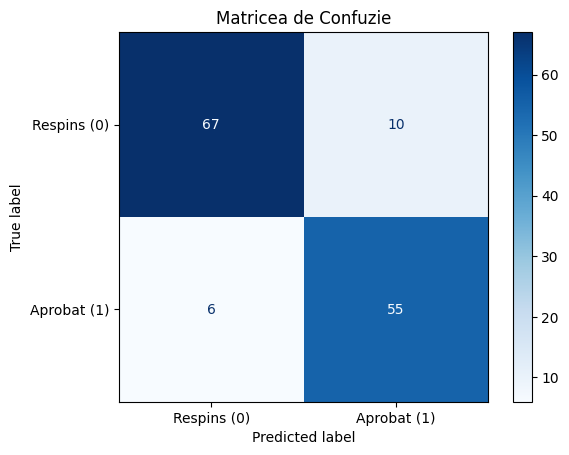

In [16]:
from sklearn.metrics import  confusion_matrix, ConfusionMatrixDisplay
y_pred_best = best_model.predict(x_test)
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Respins (0)', 'Aprobat (1)'])
disp.plot(cmap='Blues')
plt.title('Matricea de Confuzie')
plt.show()

## Analiza matrice de confuzie

Din matricea de confuzie putem observa ca modelul detecteaza mai multe false positives decat false negative lucru nu atat de favorabil din perspectiva unei banci deoarece aceasta ar prefera sa refuze preventiv o persoana pe care ulterior sa o putem aproba dupa mai multe verificari decat sa aprobe creditul unei persoane care nu ar merita sa primeasca unul si astfel sa piarda bani.

Diferenta este insa una infima fiind vorba de 10 false positives vs 6 false negatives raportate la 122 predictii corecte